# Pandas Tutorial


---



This notebook serves as an introduction to the essential data structures offered by the **Pandas** library, a cornerstone tool in the Python data science ecosystem.

Built on top of NumPy, Pandas provides a highly efficient and flexible implementation of **DataFrames**—two-dimensional, labeled data structures that support heterogeneous data types and gracefully handle missing values. These DataFrames enable powerful data manipulation capabilities through intuitive and high-level operations.

Throughout this notebook, we will use the standard alias `pd` when importing Pandas.


In [57]:
import pandas as pd
import numpy as np

## Pandas Series


A Pandas `Series` is a one-dimensional array of indexed data.

In [58]:
data = pd.Series(['Soojal','Chanchal','Amrat','Pooja','BhomSingh'])
data

0       Soojal
1     Chanchal
2        Amrat
3        Pooja
4    BhomSingh
dtype: object

The contents can be accessed in the same way as for NumPy arrays, to the difference that when more than one value is selected, the type remains a Pandas ``Series``.

In [59]:
print(data[0],type(data[0]))

Soojal <class 'str'>


In [60]:
print(data[2:],type(data[2:]))

2        Amrat
3        Pooja
4    BhomSingh
dtype: object <class 'pandas.core.series.Series'>


The type ``Series`` wraps both a sequence of values and a sequence of indices, which we can access with the <tt>values</tt> and <tt>index</tt> attributes.

* ``values`` are the contents of the series as a NumPy array

In [61]:
print(data.values,type(data.values))

['Soojal' 'Chanchal' 'Amrat' 'Pooja' 'BhomSingh'] <class 'numpy.ndarray'>


* ``index`` are the indices of the series

In [62]:
print(data.index,type(data.index))

RangeIndex(start=0, stop=5, step=1) <class 'pandas.core.indexes.range.RangeIndex'>


### Series Indices

The main difference between NumPy arrays and Pandas Series is the presence of this <tt>index</tt> field. By default, it is set (as in NumPy arrays) as <tt>0,1,..,size_of_the_series</tt> but a Series index can be explicitly defined. The indices may be numbers but also strings. Then, the contents of the series *have to* be accessed using these defined indices.

In [63]:
data = pd.Series(['Soojal','Chanchal','Amrat','Pooja','BhomSingh'], index=['a', 'b', 'c', 'd','e'])
print(data)

a       Soojal
b     Chanchal
c        Amrat
d        Pooja
e    BhomSingh
dtype: object


In [64]:
print(data['a'])

Soojal


In [65]:
data = pd.Series(['Soojal','Chanchal','Amrat','Pooja','BhomSingh'], index=[1, 3, 4, 2,5])
print(data)

1       Soojal
3     Chanchal
4        Amrat
2        Pooja
5    BhomSingh
dtype: object


In [66]:
print(data[1])

Soojal


### Series and Python Dictionaries

Pandas Series and Python Dictionaries are close semantically: mappping keys to values. However, the implementation of Pandas series is usually more efficient than dictionaries in the context of data science. Naturally, Series can be contructed from dictionaries.

In [67]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
print(population_dict,type(population_dict))
print(population,type(population))

{'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135} <class 'dict'>
California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


In [68]:
population['Florida']

np.int64(19552860)

In [69]:
population['California':'New York']

California    38332521
Texas         26448193
New York      19651127
dtype: int64

## Pandas DataFrames

DataFrames is a fundamental object of Pandas that mimicks what can be found in `R` for instance. Dataframes can be seen as an array of Series: to each `index` (corresponding to an individual for instance or a line in a table), a Dataframe maps multiples values; these values corresponds to the `columns` of the DataFrame which each have a name (as a string).   


In the following example, we will construct a Dataframe from two Series with common indices.

In [70]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})

In [71]:
states = pd.DataFrame({'Population': population, 'Area': area})
print(states,type(states))

            Population    Area
California    38332521  423967
Texas         26448193  695662
New York      19651127  141297
Florida       19552860  170312
Illinois      12882135  149995 <class 'pandas.core.frame.DataFrame'>


In Jupyter notebooks, DataFrames are displayed in a fancier way when the name of the dataframe is typed (instead of using <tt>print</tt>)

In [72]:
type(states)

pandas.core.frame.DataFrame

DataFrames have
* <tt>index</tt> that are the defined indices as in Series
* <tt>columns</tt> that are the columns names
* <tt>values</tt> that return a (2D) NumPy array with the contents

In [73]:
print(states.index)
print(states.columns)
print(states.values,type(states.values),states.values.shape)

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object')
Index(['Population', 'Area'], dtype='object')
[[38332521   423967]
 [26448193   695662]
 [19651127   141297]
 [19552860   170312]
 [12882135   149995]] <class 'numpy.ndarray'> (5, 2)


*Warning:*  When accessing a Dataframe, `dataframe_name[column_name]` return the corresponding column as a Series. `dataframe_name[index_name]` returns an error! We will see later how to access a specific index.

In [74]:
print(states['Area'],type(states['Area']))

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64 <class 'pandas.core.series.Series'>


In [75]:
try:
    print(states['California'])
except KeyError as error:
    print("KeyError: ",error)

KeyError:  'California'


### Dataframe creation

To create DataFrames, the main methods are:
* from Series (as above)

In [76]:
print(population,type(population))
states = pd.DataFrame({'Population': population, 'Area': area})
states

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


* from NumPy arrays (the columns and indices are taken as the array's ones)

In [77]:
A = np.random.randn(5,3)
print(A,type(A))
dfA = pd.DataFrame(A)
dfA

[[ 0.31581761  0.72600378  1.71360448]
 [-0.68912292 -1.10131448 -0.4901127 ]
 [-0.17088115 -1.26218054  0.22560827]
 [-0.25555333 -0.45832418  0.64684994]
 [-0.42007191 -0.08038754 -0.04911052]] <class 'numpy.ndarray'>


,0,1,2
0,0.315818,0.726004,1.713604
1,-0.689123,-1.101314,-0.490113
2,-0.170881,-1.262181,0.225608
3,-0.255553,-0.458324,0.646850
4,-0.420072,-0.080388,-0.049111


* from a *list* of *dictionaries*. Be careful, each element of the list is an example (corresponding to an automatic index 0,1,...) while each key of the dictonary corresponds to a column.

In [78]:
data = [{'a': i, 'b': 2 * i} for i in range(3)]
print(data,type(data))
print(data[0],type(data[0]))

[{'a': 0, 'b': 0}, {'a': 1, 'b': 2}, {'a': 2, 'b': 4}] <class 'list'>
{'a': 0, 'b': 0} <class 'dict'>


In [79]:
df = pd.DataFrame(data)
df

,a,b
0,0,0
1,1,2
2,2,4


* from a *file* , typically a <tt>csv</tt> file (for comma separated values), eventually with the names of the columns as a first line.


    col_1_name,col_2_name,col_3_name
    col_1_v1,col_2_v1,col_3_v1
    col_1_v2,col_2_v2,col_3_v2
    ...
    
For other files types (MS Excel, libSVM, any other separator) see this [part of the doc](https://pandas.pydata.org/pandas-docs/stable/api.html#input-output)

In [80]:
#!head -4 data/president_heights.csv # bash command to see the first 4 lines of the file

In [81]:
data = pd.read_csv('president_heights.csv')
data

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183
5,6,John Quincy Adams,171
6,7,Andrew Jackson,185
7,8,Martin Van Buren,168
8,9,William Henry Harrison,173
9,10,John Tyler,183


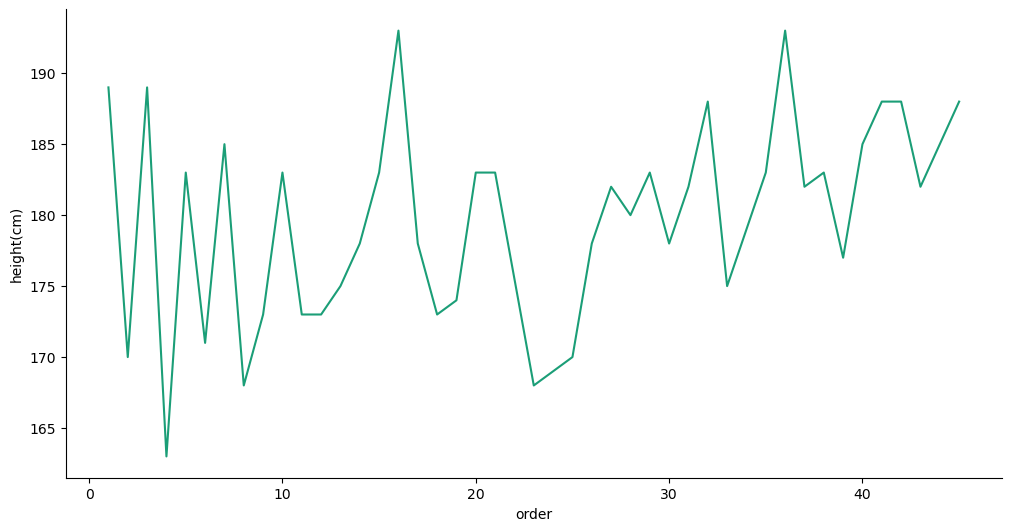

In [82]:
# @title order vs height(cm)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['order']
  ys = series['height(cm)']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('order', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('order')
_ = plt.ylabel('height(cm)')

### Names and Values

Notice there can be missing values in DataFrames.

In [83]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


You can set indices and columns names *a posteriori*

In [84]:
dfA.columns = ['a','b','c']
dfA.index = [i**2 for i in range(1,6)  ]
dfA

,a,b,c
1,0.315818,0.726004,1.713604
4,-0.689123,-1.101314,-0.490113
9,-0.170881,-1.262181,0.225608
16,-0.255553,-0.458324,0.646850
25,-0.420072,-0.080388,-0.049111


## Indexing




In [85]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})
states = pd.DataFrame({'Population': population, 'Area': area})
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


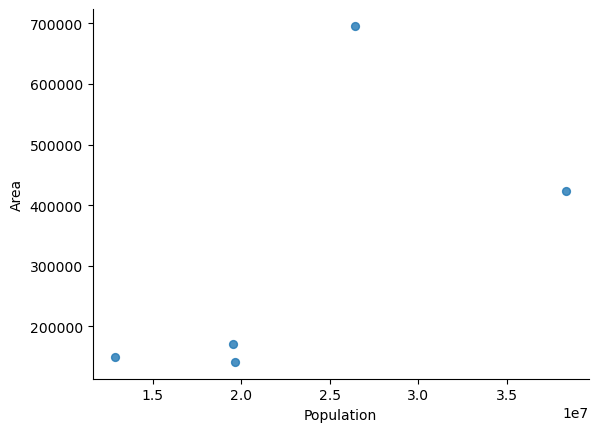

In [86]:
# @title Population vs Area

from matplotlib import pyplot as plt
states.plot(kind='scatter', x='Population', y='Area', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

You may access columns directly with names, *then* you can access individuals with their index.

In [87]:
states['Area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64

In [88]:
states['Area']['Texas']

np.int64(695662)

To ease the access, Pandas offers dedicated methods:
* <tt>iloc</tt> enables to access subparts of the dataframe as if it was a NumPy array.

In [89]:
states.iloc[:2]

,Population,Area
California,38332521,423967
Texas,26448193,695662


In [90]:
states.iloc[:2,0]

California    38332521
Texas         26448193
Name: Population, dtype: int64

* <tt>loc</tt> does the same but with the explicit names (the last one is included)

In [91]:
states.loc[:'New York']

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [92]:
states.loc[:,'Population':]

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


## Questions and Exercises

**1. Series:**
   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
   - Access the third element of the Series.
   - What is the data type of the Series?

**2. DataFrames:**
   - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
   - Add three rows to the DataFrame with the following data:
     - Name: 'Alice', Age: 25
     - Name: 'Bob', Age: 30
     - Name: 'Charlie', Age: 35
   - Access the 'Age' column of the DataFrame.
   - What is the shape of the DataFrame?

**3. Indexing:**
   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
   - Access the age of 'Alice' using `iloc`.

**4. File I/O:**
   - Read the 'president_heights.csv' file into a DataFrame.
   - What is the average height of the presidents?
   - What is the name of the tallest president?

**5. Advanced:**
   - Create a DataFrame with three columns: 'A', 'B', and 'C'.
   - Fill the DataFrame with random numbers.
   - Calculate the mean of each column.
   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
   - Sort the DataFrame by column 'D' in descending order.

In [93]:
#1. Series:
#   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
#   - Access the third element of the Series.
#   - What is the data type of the Series?

import pandas as pd
s = pd.Series([10, 20, 30, 40, 50])
print("Third element:", s[2])
print("Data type:", s.dtype)

Third element: 30
Data type: int64


In [94]:
#2. DataFrames:
#  - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
#  - Add three rows to the DataFrame with the following data:
#    - Name: 'Alice', Age: 25
#    - Name: 'Bob', Age: 30
#    - Name: 'Charlie', Age: 35
#  - Access the 'Age' column of the DataFrame.
#  - What is the shape of the DataFrame?
df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35]
})
print(df)
ag = df['Age']
print(ag)

df.shape


      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   35
0    25
1    30
2    35
Name: Age, dtype: int64


(3, 2)

In [95]:
#3. Indexing:
#   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
#  - Access the age of 'Alice' using `iloc`.
df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35]
})

df = df.set_index("Name")

print(df.loc["Bob"])

print("Alice's Age:", df.iloc[0, 0])

Age    30
Name: Bob, dtype: int64
Alice's Age: 25


In [96]:
#4. File I/O:
#   - Read the 'president_heights.csv' file into a DataFrame.
#  - What is the average height of the presidents?
#   - What is the name of the tallest president?
df = pd.read_csv('president_heights.csv')

avg_hei = df['height(cm)'].mean()
print(avg_hei)

tallest = df.loc[df["height(cm)"].idxmax()]
print("Tallest President:", tallest["name"])

179.93023255813952
Tallest President: Abraham Lincoln


In [97]:
#5. Advanced:
#  - Create a DataFrame with three columns: 'A', 'B', and 'C'.
#  - Fill the DataFrame with random numbers.
#  - Calculate the mean of each column.
#   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
#   - Sort the DataFrame by column 'D' in descending order.

df = pd.DataFrame(np.random.rand(5, 3), columns=["A", "B", "C"])

print(df.mean())

df["D"] = df["A"] + df["B"]

print("\nUpdated DataFrame:")
print(df)

A    0.494455
B    0.647177
C    0.728541
dtype: float64

Updated DataFrame:
          A         B         C         D
0  0.621802  0.712684  0.481828  1.334486
1  0.959344  0.856430  0.879528  1.815775
2  0.300177  0.755186  0.873053  1.055363
3  0.118460  0.054516  0.862653  0.172976
4  0.472492  0.857068  0.545644  1.329561
